<a href="https://colab.research.google.com/github/miller00315/ia_studies/blob/main/xgboost.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay,
    roc_auc_score,
    RocCurveDisplay)

In [13]:
RANDOM_STATE = 7895

In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/vqrca/ml-datasets/refs/heads/main/BankChurners_portugues.csv')

In [3]:
pd.set_option('display.max_columns', None)
print(df.head())

   Numero_Cliente Target  Idade_Cliente     Genero  Numero_Dependentes  \
0       768805383  Ativo             45  Masculino                   3   
1       818770008  Ativo             49   Feminino                   5   
2       713982108  Ativo             51  Masculino                   3   
3       769911858  Ativo             40   Feminino                   4   
4       709106358  Ativo             40  Masculino                   3   

              Escolaridade   Estado_Civil         Faixa_Renda_Anual  \
0             Ensino medio      Casado(a)   US$ 60 mil a US$ 80 mil   
1                Graduacao    Solteiro(a)       Menos de US$ 40 mil   
2                Graduacao      Casado(a)  US$ 80 mil a US$ 120 mil   
3             Ensino medio  Nao informado       Menos de US$ 40 mil   
4  Sem escolaridade formal      Casado(a)   US$ 60 mil a US$ 80 mil   

  Categoria_Cartao  Meses_Como_Cliente  Quantidade_Produtos_Banco  \
0             Azul                  39                     

In [4]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 21 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Numero_Cliente                        10127 non-null  int64  
 1   Target                                10127 non-null  object 
 2   Idade_Cliente                         10127 non-null  int64  
 3   Genero                                10127 non-null  object 
 4   Numero_Dependentes                    10127 non-null  int64  
 5   Escolaridade                          10127 non-null  object 
 6   Estado_Civil                          10127 non-null  object 
 7   Faixa_Renda_Anual                     10127 non-null  object 
 8   Categoria_Cartao                      10127 non-null  object 
 9   Meses_Como_Cliente                    10127 non-null  int64  
 10  Quantidade_Produtos_Banco             10127 non-null  int64  
 11  Meses_Inativo_U

In [5]:
colunas_categoricas = df.select_dtypes(include='object').columns

df[colunas_categoricas] = df[colunas_categoricas].astype('category')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 21 columns):
 #   Column                                Non-Null Count  Dtype   
---  ------                                --------------  -----   
 0   Numero_Cliente                        10127 non-null  int64   
 1   Target                                10127 non-null  category
 2   Idade_Cliente                         10127 non-null  int64   
 3   Genero                                10127 non-null  category
 4   Numero_Dependentes                    10127 non-null  int64   
 5   Escolaridade                          10127 non-null  category
 6   Estado_Civil                          10127 non-null  category
 7   Faixa_Renda_Anual                     10127 non-null  category
 8   Categoria_Cartao                      10127 non-null  category
 9   Meses_Como_Cliente                    10127 non-null  int64   
 10  Quantidade_Produtos_Banco             10127 non-null  int64   
 11  Me

In [7]:
X = df.drop(['Numero_Cliente', 'Target'], axis=1)
y = df['Target']

In [8]:
X.head()

,Idade_Cliente,Genero,Numero_Dependentes,Escolaridade,Estado_Civil,Faixa_Renda_Anual,Categoria_Cartao,Meses_Como_Cliente,Quantidade_Produtos_Banco,Meses_Inativo_Ultimos_12_Meses,Contatos_Ultimos_12_Meses,Limite_Credito,Saldo_Rotativo_Total,Credito_Disponivel_Medio,Variacao_Valor_Transacoes_T4_T1,Valor_Total_Transacoes,Quantidade_Total_Transacoes,Variacao_Quantidade_Transacoes_T4_T1,Taxa_Media_Utilizacao_Credito
0,45,Masculino,3,Ensino medio,Casado(a),US$ 60 mil a US$ 80 mil,Azul,39,5,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,49,Feminino,5,Graduacao,Solteiro(a),Menos de US$ 40 mil,Azul,44,6,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,51,Masculino,3,Graduacao,Casado(a),US$ 80 mil a US$ 120 mil,Azul,36,4,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,40,Feminino,4,Ensino medio,Nao informado,Menos de US$ 40 mil,Azul,34,3,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,40,Masculino,3,Sem escolaridade formal,Casado(a),US$ 60 mil a US$ 80 mil,Azul,21,5,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000


In [9]:
y.head()

,Target
0,Ativo
1,Ativo
2,Ativo
3,Ativo
4,Ativo


In [10]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y = le.fit_transform(df['Target'])

In [11]:
y

array([0, 0, 0, ..., 1, 1, 1])

In [14]:
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE)

In [15]:
import xgboost as xgb

In [16]:
modelo_xgboost = xgb.XGBClassifier(objective='binary:logistic',
                                   random_state=RANDOM_STATE
)
modelo_xgboost.fit(X_treino, y_treino)
predicoes = modelo_xgboost.predict(X_teste)

In [17]:
acuracia_teste = accuracy_score(y_teste, predicoes)
print(f'Acurácia do XGBoost nos dados de teste: {acuracia_teste:.2f}')

Acurácia do XGBoost nos dados de teste: 0.97


In [18]:
predicoes_treino = modelo_xgboost.predict(X_treino)
acuracia = accuracy_score(y_treino, predicoes_treino)
print(f'Acurácia do XGBoost nos dados de treino: {acuracia:.2f}')

Acurácia do XGBoost nos dados de treino: 1.00


In [19]:
report = classification_report(y_teste, predicoes)
print(report)

              precision    recall  f1-score   support

           0       0.97      0.99      0.98      1701
           1       0.94      0.85      0.89       325

    accuracy                           0.97      2026
   macro avg       0.96      0.92      0.94      2026
weighted avg       0.97      0.97      0.97      2026



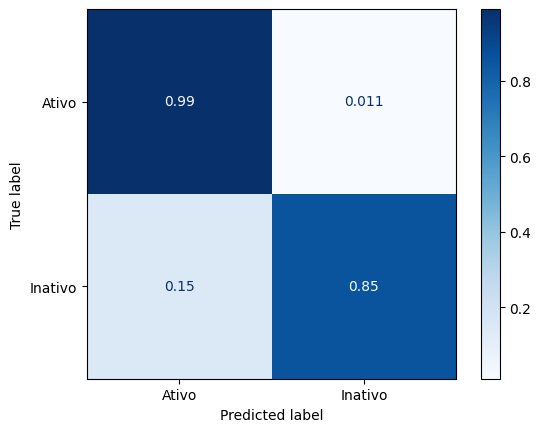

In [20]:
ConfusionMatrixDisplay.from_estimator(modelo_xgboost,
                                      X_teste, y_teste,
                                      normalize = 'true',
                                      cmap = 'Blues',
                                      display_labels=['Ativo', 'Inativo']);

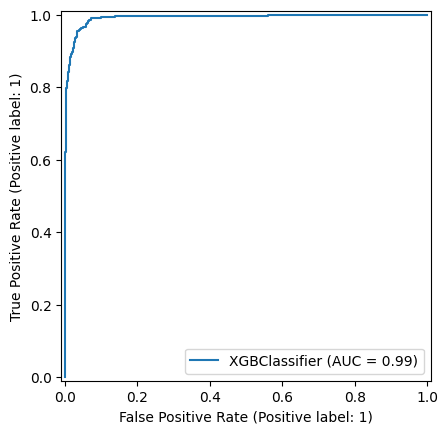

In [21]:
RocCurveDisplay.from_estimator(
    modelo_xgboost,
    X_teste,
    y_teste
);


In [22]:
dmatrix = xgb.DMatrix(data=X, label=y)

params = {'objective': 'binary:logistic'}

cv_resultados = xgb.cv(dtrain=dmatrix, params=params, nfold=3,
                       num_boost_round=5, metrics='error',
                       as_pandas=True, seed=5678)

print(cv_resultados)
acuracia = 1 - cv_resultados['test-error-mean'].iloc[-1]
print(f'Acuracia: {acuracia}')


   train-error-mean  train-error-std  test-error-mean  test-error-std
0          0.107040         0.008024         0.109313        0.007176
1          0.062161         0.004322         0.074850        0.005609
2          0.046016         0.003699         0.062704        0.002120
3          0.037474         0.001833         0.056680        0.000616
4          0.031549         0.000793         0.050262        0.002441
Acuracia: 0.9497380492656954


In [24]:
params = {'objective': 'binary:logistic'}

cv_resultados = xgb.cv(dtrain=dmatrix, params=params, nfold=3,
                       num_boost_round=200, early_stopping_rounds=5,
                       metrics='error', as_pandas=True, seed=5678)

print(cv_resultados)
acuracia = 1 - cv_resultados['test-error-mean'].iloc[-1]
print(f'Acuracia: {acuracia}')

    train-error-mean  train-error-std  test-error-mean  test-error-std
0           0.107040         0.008024         0.109313        0.007176
1           0.062161         0.004322         0.074850        0.005609
2           0.046016         0.003699         0.062704        0.002120
3           0.037474         0.001833         0.056680        0.000616
4           0.031549         0.000793         0.050262        0.002441
5           0.027797         0.001176         0.046312        0.001821
6           0.025477         0.001375         0.045127        0.002806
7           0.023650         0.001145         0.042263        0.002449
8           0.020095         0.001817         0.041078        0.003458
9           0.018663         0.001228         0.039597        0.003304
10          0.017132         0.000699         0.039005        0.001419
11          0.015306         0.000788         0.038314        0.002669
12          0.013973         0.001098         0.038017        0.003296
13    

In [25]:
params = {'objective': 'binary:logistic',
          'learning_rate': 0.01}

cv_resultados = xgb.cv(dtrain=dmatrix, params=params, nfold=3,
                       num_boost_round=100,
                       metrics='error', as_pandas=True, seed=123)

print(cv_resultados)
acuracia = 1 - cv_resultados['test-error-mean'].iloc[-1]
print(f'Acuracia: {acuracia}')


    train-error-mean  train-error-std  test-error-mean  test-error-std
0           0.160660         0.003034         0.160660        0.006068
1           0.160660         0.003034         0.160660        0.006068
2           0.160660         0.003034         0.160660        0.006068
3           0.160660         0.003034         0.160660        0.006068
4           0.160660         0.003034         0.160660        0.006068
..               ...              ...              ...             ...
95          0.047546         0.001274         0.062506        0.003645
96          0.047052         0.001458         0.062012        0.003743
97          0.046164         0.001578         0.061123        0.003150
98          0.045621         0.001425         0.060531        0.003624
99          0.045028         0.001261         0.060432        0.003748

[100 rows x 4 columns]
Acuracia: 0.9395679304897314


In [26]:
params = {'objective': 'binary:logistic',
          'learning_rate': 0.1}

cv_resultados = xgb.cv(dtrain=dmatrix, params=params, nfold=3,
                       num_boost_round=100,
                       metrics='error', as_pandas=True, seed=123)

print(cv_resultados)
acuracia = 1 - cv_resultados['test-error-mean'].iloc[-1]
print(f'Acuracia: {acuracia}')

    train-error-mean  train-error-std  test-error-mean  test-error-std
0           0.160660         0.003034         0.160660        0.006068
1           0.160660         0.003034         0.160660        0.006068
2           0.160660         0.003034         0.160660        0.006068
3           0.160660         0.003034         0.160660        0.006068
4           0.132368         0.007551         0.135975        0.012511
..               ...              ...              ...             ...
95          0.003555         0.000320         0.029031        0.001351
96          0.003456         0.000349         0.029031        0.001213
97          0.003407         0.000419         0.029031        0.000971
98          0.003308         0.000489         0.029031        0.000643
99          0.003357         0.000489         0.029130        0.000918

[100 rows x 4 columns]
Acuracia: 0.9708698730325902


In [27]:
params = {'objective': 'binary:logistic',
          'learning_rate': 1}

cv_resultados = xgb.cv(dtrain=dmatrix, params=params, nfold=3,
                       num_boost_round=100,
                       metrics='error', as_pandas=True, seed=123)

print(cv_resultados)
acuracia = 1 - cv_resultados['test-error-mean'].iloc[-1]
print(f'Acuracia: {acuracia}')


    train-error-mean  train-error-std  test-error-mean  test-error-std
0           0.049373         0.001751         0.067344        0.003773
1           0.040437         0.000758         0.061913        0.005905
2           0.031549         0.002499         0.057371        0.004524
3           0.024143         0.004458         0.052928        0.002422
4           0.018219         0.004133         0.049077        0.000913
..               ...              ...              ...             ...
95          0.000000         0.000000         0.036437        0.002106
96          0.000000         0.000000         0.036437        0.002329
97          0.000000         0.000000         0.036042        0.002165
98          0.000000         0.000000         0.036338        0.001844
99          0.000000         0.000000         0.036437        0.001916

[100 rows x 4 columns]
Acuracia: 0.9635629278567667


In [28]:
params = {
    'learning_rate': [0.1, 0.2, 0.3],
    'max_depth': [5, 10, 15],
    'colsample_bytree': [0.5, 1.0],
    'n_estimators': [50, 100],
    'reg_lambda': [1, 5, 10],
    'reg_alpha':  [0, 0.1, 1],
    'gamma':      [0, 0.1, 1],
    'min_child_weight': [1, 5]
}

modelo_xgb = xgb.XGBClassifier(random_state=RANDOM_STATE)

random_search_cv = RandomizedSearchCV(estimator=modelo_xgb, param_distributions=params, n_iter=5, cv=4, scoring='recall',
                                      verbose=1, random_state=765)

random_search_cv.fit(X,y)

print('Melhores parametros encontrados: ', random_search_cv.best_params_)
print('Recall:', random_search_cv.best_score_)

Fitting 4 folds for each of 5 candidates, totalling 20 fits
Melhores parametros encontrados:  {'reg_lambda': 1, 'reg_alpha': 0, 'n_estimators': 50, 'min_child_weight': 5, 'max_depth': 5, 'learning_rate': 0.3, 'gamma': 0.1, 'colsample_bytree': 0.5}
Recall: 0.6924117355151838


In [29]:
modelo_xgboost_ajustado = random_search_cv.best_estimator_
predicoes_xgboost_ajustado = modelo_xgboost_ajustado.predict(X_teste)
acuracia = accuracy_score(y_teste, predicoes_xgboost_ajustado)
print(f"Acurácia do XGBoost ajustado nos dados de teste: {acuracia:.2%}")

Acurácia do XGBoost ajustado nos dados de teste: 99.21%


In [30]:
predicoes_xgboost_ajustado_treino = modelo_xgboost_ajustado.predict(X_treino)
acuracia = accuracy_score(y_treino, predicoes_xgboost_ajustado_treino)
print(f"Acurácia do XGBoost ajustado nos dados de treino: {acuracia:.2%}")

Acurácia do XGBoost ajustado nos dados de treino: 99.05%


In [31]:
report = classification_report(y_teste, predicoes_xgboost_ajustado)
print(report)

              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1701
           1       0.98      0.97      0.98       325

    accuracy                           0.99      2026
   macro avg       0.99      0.98      0.99      2026
weighted avg       0.99      0.99      0.99      2026



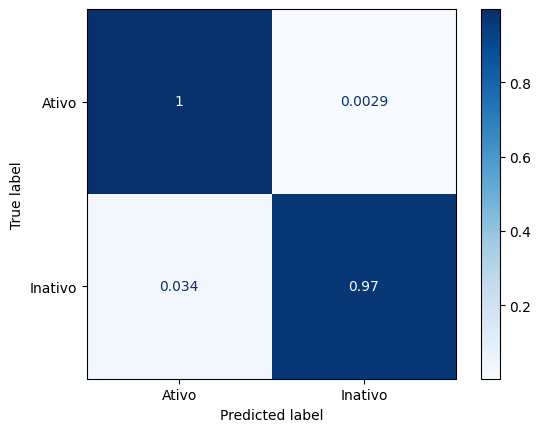

In [32]:
ConfusionMatrixDisplay.from_estimator(modelo_xgboost_ajustado,
                                      X_teste, y_teste,
                                      normalize = 'true', cmap = 'Blues',
                                      display_labels=['Ativo', 'Inativo']);

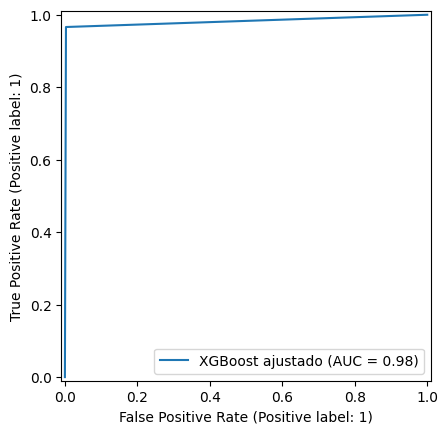

In [33]:
RocCurveDisplay.from_predictions(y_teste, predicoes_xgboost_ajustado,
                                 name='XGBoost ajustado');

In [34]:
importancias = (
    pd.Series(
        modelo_xgboost_ajustado.feature_importances_,
        index=X_treino.columns
    )
    .sort_values(ascending=False)
)

print(importancias.head(15))

Quantidade_Produtos_Banco               0.200761
Saldo_Rotativo_Total                    0.160979
Quantidade_Total_Transacoes             0.139934
Valor_Total_Transacoes                  0.101756
Variacao_Quantidade_Transacoes_T4_T1    0.089085
Idade_Cliente                           0.043637
Variacao_Valor_Transacoes_T4_T1         0.034413
Meses_Inativo_Ultimos_12_Meses          0.034281
Limite_Credito                          0.033657
Genero                                  0.030042
Contatos_Ultimos_12_Meses               0.027528
Credito_Disponivel_Medio                0.022265
Estado_Civil                            0.021729
Meses_Como_Cliente                      0.016060
Numero_Dependentes                      0.014020
dtype: float32
